In [2]:
!pip install pandas matplotlib seaborn plotly jinja2 nbformat ipywidgets

## **Análisis de Ventas y Marketing**

### **1.1: Recopilación y Preparación de Datos**


*   Como primer paso, se importan los datos desde google drive para no perder el progreso.
*   Se importa pandas, que es una librería que nos permite trabajar con las tablas y convertirlas en dataframes.



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

sns.set_theme(style="whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')

from etl_pipeline import extract_data, transform_data

df_v, df_c, df_m = extract_data()

df_ventas, df_clientes, df_marketing = transform_data(df_v, df_c, df_m) 

df_ventas.head()

Iniciando extracción de datos...
Iniciando transformación de datos...
Transformación completada con éxito.


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,106.21,4.0,02/01/2024,Electrodomésticos


## **1.2: Cálculo de Ventas Mensuales**



*  Se pide calcular el total de ventas con un script básico. Los pasos son:
0.   Limpiar los datos.
1.   Calcular el ingreso total por cada venta (precio x cantidad)
2.   Clasificar la venta por mes.
3.   Agrupar todas las ventas por mes y sumarlas.





In [4]:
# Copia del dataframe para no modificar el original

df_ventas_calculo = df_ventas.copy()

# 0. LIMPIAR DATOS:

df_ventas_calculo["fecha_venta"] = pd.to_datetime(df_ventas_calculo["fecha_venta"], format="%d/%m/%Y")

# 1. REALIZAR CALCULOS

# Ingreso total por venta
df_ventas_calculo["ingreso_total"] = df_ventas_calculo["precio"] * df_ventas_calculo["cantidad"]

# 2. & 3. AGRUPAR POR MES

# Extraer el mes
df_ventas_calculo["mes"] = df_ventas_calculo["fecha_venta"].dt.month

# Agrupar por mes
ventas_mensuales = df_ventas_calculo.groupby('mes')['ingreso_total'].sum()

print("--- Ventas Totales por Mes ---")
print(ventas_mensuales)

--- Ventas Totales por Mes ---
mes
1     129604.99
2     118672.44
3     136779.15
4     128430.69
5     143727.25
6     108480.17
7     116229.97
8     119680.15
9     115787.85
10    112117.13
11    119951.79
12    117631.94
Name: ingreso_total, dtype: float64


## **1.3: Almacenamiento de datos en diccionarios**

Se elije diccionarios ya que al tener la estructura clave:valor es mucho más cómodo para usar.

In [5]:
lista_de_ventas = []

for index, row in df_ventas_calculo.iterrows():

  venta_actual = {
      "producto": row["producto"],
      "precio_unitario": row["precio"],
      "cantidad": row["cantidad"]
  }

  lista_de_ventas.append(venta_actual)

print("Lista de Diccionarios (Primeras 5 filas):")

for venta in lista_de_ventas[:5]:
  print(venta)

Lista de Diccionarios (Primeras 5 filas):
{'producto': 'Cuadro decorativo', 'precio_unitario': 69.94, 'cantidad': 5.0}
{'producto': 'Lámpara de mesa', 'precio_unitario': 105.1, 'cantidad': 5.0}
{'producto': 'Secadora', 'precio_unitario': 97.96, 'cantidad': 3.0}
{'producto': 'Heladera', 'precio_unitario': 114.35, 'cantidad': 8.0}
{'producto': 'Secadora', 'precio_unitario': 106.21, 'cantidad': 4.0}


## **1.4: realizar un análisis exploratorio inicial de los DataFrames.**

Se procede a analizar los datos de los tres dataframes:

1. Información general y tipo de datos con .info()
2. Existencia de valores nulos con .isna().sum()
3. Filas duplicadas, de existir, con -duplicated().sum()


In [6]:
# 1. Tipo de datos + info
print("INFO DE VENTAS:\n")
df_ventas.info()
print("\nINFO DE CLIENTES:\n")
df_clientes.info()
print("\nINFO DE MARKETING:\n")
df_marketing.info()

# 2. Cantidad de nulos
print("NULOS DE VENTAS:\n")
display(df_ventas.isna().sum())
print("\nNULOS DE CLIENTES:\n")
display(df_clientes.isna().sum())
print("\nNULOS DE MARKETING:\n")
display(df_marketing.isna().sum())

# 3. Filas duplicadas
print("FILAS DUPLICADAS DE VENTAS:\n")
display(df_ventas.duplicated().sum())
print("\nFILAS DUPLICADAS DE CLIENTES:\n")
display(df_clientes.duplicated().sum())
print("\nFILAS DUPLICADAS DE MARKETING:\n")
display(df_marketing.duplicated().sum())

# 4. Vista de las tablas
print("VENTAS:\n")
display(df_ventas)
print("\nCLIENTES:\n")
display(df_clientes)
print("\nMARKETING:\n")
display(df_marketing)


INFO DE VENTAS:

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     2998 non-null   int64  
 1   producto     2998 non-null   object 
 2   precio       2998 non-null   float64
 3   cantidad     2998 non-null   float64
 4   fecha_venta  2998 non-null   object 
 5   categoria    2998 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 164.0+ KB

INFO DE CLIENTES:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  567 non-null    int64  
 1   nombre      567 non-null    object 
 2   edad        567 non-null    int64  
 3   ciudad      567 non-null    object 
 4   ingresos    567 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 22.3+ KB

INFO DE

id_venta       0
producto       0
precio         0
cantidad       0
fecha_venta    0
categoria      0
dtype: int64


NULOS DE CLIENTES:



id_cliente    0
nombre        0
edad          0
ciudad        0
ingresos      0
dtype: int64


NULOS DE MARKETING:



...

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,106.21,4.0,02/01/2024,Electrodomésticos
...,...,...,...,...,...,...
3030,1837,Horno eléctrico,104.12,9.0,30/12/2024,Electrodomésticos
3031,2276,Laptop,85.27,9.0,30/12/2024,Electrónica
3032,2696,Laptop,107.81,4.0,30/12/2024,Electrónica
3033,2913,Smartphone,99.85,7.0,30/12/2024,Electrónica



CLIENTES:



,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65
...,...,...,...,...,...
562,563,Dione Forsyde,29,Posadas,26757.73
563,564,Fleming Gow,39,Santa Fe,43674.96
564,565,Jewelle Mabbett,33,Córdoba,30522.64
565,566,Lauri Munns,23,Resistencia,31259.14



MARKETING:



,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024
...,...,...,...,...,...,...
85,70,Aspiradora,TV,3.06,13/12/2024,29/12/2024
86,89,Televisor,TV,4.98,13/12/2024,8/2/2025
87,68,Rincón de plantas,TV,5.81,17/12/2024,14/2/2025
88,33,Secadora,Email,3.80,20/12/2024,7/1/2025


## **1.5: Análisis de las tablas**

### 1. Dataframe ventas:

* Compuesta por 3035 filas y 6 columnas.
* Nulos: 2 en precio y 2 en cantidad.
* Duplicados: 35 filas.
* Temas a resolver:

a. La columna precio es object (texto) por el símbolo $ y debe convertirse a numero.

b. La columna fecha_venta es object y tiene que convertirse a datetime.

c. La columna cantidad es float64 (decimal). Pasarlo a int tiene más sentido.

### 2. Dataframe clientes:

* Contiene 567 filas y 5 columnas.
* Nulos: 0.
* Duplicados: 0.

### 3. Dataframe marketing:

* Contiene 90 filas y 6 columnas.
* Nulos: 0.
* Duplicados: 0.
* Temas a resolver:

a. Las columnas fecha_inicio y fecha_fin son object y tienen que pasarse a datetime.



## **2.1: Limpieza de datos.**

Basado en los descubrimientos anteriores, se preocederá a:

1. Eliminar filas duplicadas y nulos.
2. Corregir tipo de datos en columnas.




In [7]:
# DATAFRAME VENTAS (df_ventas)

print("VENTAS =>\n")

# 0. Antes de la limpieza

print("Antes de la limpieza:\n")
print(f"Número de filas: {df_ventas.shape[0]}")
print("Tipo de datos:")
print(df_ventas.dtypes)
print(f"\nValores nulos:\n{df_ventas.isna().sum()}")
print(f"\nFilas duplicadas: {df_ventas.duplicated().sum()}")

# 1. Limpieza

df_ventas.drop_duplicates(inplace=True)
df_ventas.dropna(inplace=True)

# 2. Corrección de tipo de datos

df_ventas['cantidad'] = df_ventas['cantidad'].astype(int)
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'], format='%d/%m/%Y')

# 3. Después de la limpieza

print("\nDespués de la limpieza:\n")
print(f"Número de filas: {df_ventas.shape[0]}")
print("Tipo de datos:")
print(df_ventas.dtypes)
print(f"\nValores nulos:\n{df_ventas.isna().sum()}")
print(f"\nFilas duplicadas: {df_ventas.duplicated().sum()}")

# DATAFRAME MARKETING (df_marketing)

print("MARKETING =>\n")

# 0. Antes de la limpieza

print("Antes de la limpieza:\n")
print("Tipo de datos:")
print(df_marketing.dtypes)

# 1. Corrección de tipo de datos

df_marketing['fecha_inicio'] = pd.to_datetime(df_marketing['fecha_inicio'], dayfirst=True)
df_marketing['fecha_fin'] = pd.to_datetime(df_marketing['fecha_fin'], dayfirst=True)

# 2. Después de la limpieza

print("\nDespués de la limpieza:\n")
print("Tipo de datos:")
print(df_marketing.dtypes)

VENTAS =>

Antes de la limpieza:

Número de filas: 2998
Tipo de datos:
id_venta         int64
producto        object
precio         float64
cantidad       float64
fecha_venta     object
categoria       object
dtype: object

Valores nulos:
id_venta       0
producto       0
precio         0
cantidad       0
fecha_venta    0
categoria      0
dtype: int64

Filas duplicadas: 0

Después de la limpieza:

Número de filas: 2998
Tipo de datos:
id_venta                int64
producto               object
precio                float64
cantidad                int32
fecha_venta    datetime64[ns]
categoria              object
dtype: object

Valores nulos:
id_venta       0
producto       0
precio         0
cantidad       0
fecha_venta    0
categoria      0
dtype: int64

Filas duplicadas: 0
MARKETING =>

Antes de la limpieza:

Tipo de datos:
id_campanha       int64
producto         object
canal            object
costo           float64
fecha_inicio     object
fecha_fin        object
dtype: object

Despu

## **2.2: Productos de alto rendimiento**

Se va a tomar como "alto rendimiento" al 25% de productos que más ingresos generan.

1. Se calcula el ingreso de cada venta (precio x cantidad)

2. Sumar el ingreso total de los productos iguales.

3. Filtrar el dataframe ventas para mostrar este 25%

In [8]:
df_ventas["ingreso"] = df_ventas["precio"] * df_ventas["cantidad"]

# Agrupar por producto y sumar el ingreso total
ingresos_por_producto = df_ventas.groupby('producto')['ingreso'].sum().sort_values(ascending=False)

# .quantile(0.75) sirve para encontrar el valor que marca el inicio del 25% superior
umbral_alto_rendimiento = ingresos_por_producto.quantile(0.75)

# Se crea un alista con los nombres de estos 25% de productos
productos_alto_rendimiento = ingresos_por_producto[ingresos_por_producto >= umbral_alto_rendimiento].index.tolist()

# Nuevo df
df_ventas_alto_rendimiento = df_ventas[df_ventas['producto'].isin(productos_alto_rendimiento)]

print(f"Limite de ingresos para ser considerado 'Alto Rendimiento' (25%): ${umbral_alto_rendimiento:,.2f}")
print(f"Número de productos que cumplen esto: {len(productos_alto_rendimiento)}")
print(f"Número total de ventas de estos productos: {df_ventas_alto_rendimiento.shape[0]}")

display(df_ventas_alto_rendimiento)


Limite de ingresos para ser considerado 'Alto Rendimiento' (25%): $51,092.96
Número de productos que cumplen esto: 8
Número total de ventas de estos productos: 972


,id_venta,producto,precio,cantidad,fecha_venta,categoria,ingreso
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.70
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50
2,1156,Secadora,97.96,3,2024-01-02,Electrodomésticos,293.88
4,1546,Secadora,106.21,4,2024-01-02,Electrodomésticos,424.84
18,794,Jarrón decorativo,96.97,7,2024-01-04,Decoración,678.79
...,...,...,...,...,...,...,...
3019,639,Lámpara de mesa,51.77,7,2024-12-29,Decoración,362.39
3023,1893,Microondas,89.88,3,2024-12-29,Electrodomésticos,269.64
3028,909,Lámpara de mesa,35.85,5,2024-12-30,Decoración,179.25
3029,1583,Microondas,105.36,9,2024-12-30,Electrodomésticos,948.24


##  2.3: agregación

Un vez que los datos de hayan limpiado, se procede a resumirlos para porder verlos de forma correcta. Se van a utilizar funciones de agregación y agrupamiento.

Métricas clave: total vendido, ticket promedio y cantidad de operaciones por categoría.

In [9]:
resumen_por_categoria = df_ventas.groupby("categoria").agg(
      total_vendido=("ingreso", "sum"),
      ticket_promedio=("ingreso", "mean"),
      cantidad_operaciones=("id_venta", "count"),
      items_vendidos=("cantidad", "sum"),
      precio_promedio_prod=("precio", "mean")
  ).sort_values(by="total_vendido", ascending=False).reset_index()

print("Resumen por Categoría:")
display(resumen_por_categoria)

Resumen por Categoría:


,categoria,total_vendido,ticket_promedio,cantidad_operaciones,items_vendidos,precio_promedio_prod
0,Electrodomésticos,505299.63,505.29963,1000,6592,76.52096
1,Electrónica,482577.80,483.54489,998,6413,75.25492
2,Decoración,479216.09,479.21609,1000,6490,74.09800


##  2.4: Integración de datos

Como último punto, se integraran los datos de ventas con los de marketing para analizar la efectividad de las campañas publicitarias.

Para lograrlo, voy a unir dos tablas y filtrar las ventas por periodo de campaña activo.

In [10]:
df_integrado = pd.merge(df_ventas, df_marketing, on='producto', how='inner')

condicion_fecha = (df_integrado['fecha_venta'] >= df_integrado['fecha_inicio']) & \
                  (df_integrado['fecha_venta'] <= df_integrado['fecha_fin'])

df_ventas_en_campanha = df_integrado[condicion_fecha]

# ANALISIS
resumen_por_canal = (
    df_ventas_en_campanha.groupby('canal')
    .agg(
        ingresos_generados=("ingreso", "sum"),
        ventas_realizadas=("id_venta", "count")
    )
    .sort_values("ingresos_generados", ascending=False)
    .reset_index()
)


# IMPRIMIR RESULTADOS
print(f"Se encontraron {df_ventas_en_campanha.shape[0]} ventas que ocurrieron durante una campaña de marketing activa.")

print("\nTabla de ventas ocurridas durante campañas:")
display(df_ventas_en_campanha[['producto', 'fecha_venta', 'ingreso', 'canal', 'fecha_inicio', 'fecha_fin']])

print("\nResumen de Efectividad de Campañas por Canal:")
display(resumen_por_canal.style.format({
    'ingresos_generados': '${:,.2f}',
    'ventas_realizadas': '{:,}'
}))

Se encontraron 847 ventas que ocurrieron durante una campaña de marketing activa.

Tabla de ventas ocurridas durante campañas:


,producto,fecha_venta,ingreso,canal,fecha_inicio,fecha_fin
2073,Adorno de pared,2024-03-20,698.52,TV,2024-03-20,2024-05-03
2091,Adorno de pared,2024-03-21,553.91,TV,2024-03-20,2024-05-03
2124,Adorno de pared,2024-03-22,579.54,TV,2024-03-20,2024-05-03
2160,Adorno de pared,2024-03-24,286.68,TV,2024-03-20,2024-05-03
2256,Adorno de pared,2024-03-28,831.20,TV,2024-03-20,2024-05-03
...,...,...,...,...,...,...
8957,Freidora eléctrica,2024-12-29,199.36,RRSS,2024-12-29,2025-01-21
8969,Alfombra,2024-12-30,675.06,RRSS,2024-11-27,2025-01-08
8972,Rincón de plantas,2024-12-30,896.16,TV,2024-12-17,2025-02-14
8984,Laptop,2024-12-30,767.43,TV,2024-11-16,2025-01-13



Resumen de Efectividad de Campañas por Canal:


,canal,ingresos_generados,ventas_realizadas
0,Email,"$152,161.04",307
1,TV,"$139,197.11",276
2,RRSS,"$125,449.52",264


# 3: Análisis de Datos

## 3.1: Estadística Descriptiva

Primero, se calcula las métricas sobre ventas generales y luego se crea una tabla para el análisis.

In [11]:
df_ventas['ingresos'] = df_ventas['precio'] * df_ventas['cantidad']

# 1. Estadística descriptiva sobre el DataFrame de ventas limpio
print("ESTADÍSTICAS DESCRIPTIVAS DE VENTAS GENERALES\n")
estadisticas_ventas = df_ventas[['precio', 'cantidad', 'ingresos']].describe()
display(estadisticas_ventas)

# 2. Creación de DataFrame Consolidado por Producto
# Agrupar ventas por producto
grp_ventas = df_ventas.groupby('producto').agg(
    ventas_total=('ingresos', 'sum'),
    unidades_vendidas=('cantidad', 'sum'),
    categoria=('categoria', 'first'),
    cantidad_operaciones=('id_venta', 'count')
).reset_index()

# Agrupar marketing por producto
grp_mkt = df_marketing.groupby('producto')['costo'].sum().reset_index()
grp_mkt.rename(columns={'costo': 'inversion_total'}, inplace=True)

# Merge de Ventas y Marketing
prod_global = pd.merge(grp_ventas, grp_mkt, on='producto', how='left')

# Llenar con 0 si no hubo inversión en marketing para ese producto
prod_global['inversion_total'] = prod_global['inversion_total'].fillna(0)

# Cálculo de Indicadores Clave (KPIs)
prod_global['ticket_medio'] = prod_global['ventas_total'] / prod_global['cantidad_operaciones']

# ROAS: Retorno de la inversión publicitaria (Ventas / Inversión)
prod_global['ROAS'] = prod_global.apply(
    lambda x: x['ventas_total'] / x['inversion_total'] if x['inversion_total'] > 0 else 0, axis=1
)

print("\nDATAFRAME:")
display(prod_global)

print("\nESTADÍSTICAS POR PRODUCTO (KPIs):")
columnas_prod = ['ventas_total', 'unidades_vendidas', 'ticket_medio', 'ROAS', 'inversion_total']
display(prod_global[columnas_prod].describe())


ESTADÍSTICAS DESCRIPTIVAS DE VENTAS GENERALES



,precio,cantidad,ingresos
count,2998.000000,2998.000000,2998.000000
mean,75.291318,6.502668,489.357412
std,28.736008,3.455107,334.281817
min,26.000000,1.000000,26.300000
25%,50.030000,3.000000,220.920000
50%,75.205000,7.000000,418.065000
75%,100.067500,9.000000,709.920000
max,124.970000,12.000000,1488.120000



DATAFRAME:


,producto,ventas_total,unidades_vendidas,categoria,cantidad_operaciones,inversion_total,ticket_medio,ROAS
0,Adorno de pared,48093.49,633,Decoración,100,14.05,480.934900,3423.024199
1,Alfombra,44773.06,615,Decoración,100,17.46,447.730600,2564.321879
2,Aspiradora,50085.86,651,Electrodomésticos,100,16.46,500.858600,3042.883354
3,Auriculares,74175.58,958,Electrónica,143,15.24,518.710350,4867.164042
4,Batidora,50979.20,672,Electrodomésticos,100,15.28,509.792000,3336.335079
5,Cafetera,59607.31,765,Electrodomésticos,117,18.16,509.464188,3282.340859
6,Candelabro,11128.80,160,Decoración,24,14.65,463.700000,759.645051
7,Consola de videojuegos,46174.41,623,Electrónica,99,12.77,466.408182,3615.850431
8,Cortinas,44865.03,610,Decoración,100,17.36,448.650300,2584.391129
9,Cuadro decorativo,54297.60,726,Decoración,100,15.85,542.976000,3425.716088



ESTADÍSTICAS POR PRODUCTO (KPIs):


,ventas_total,unidades_vendidas,ticket_medio,ROAS,inversion_total
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,48903.117333,649.833333,488.328301,3322.292045,14.786000
std,13265.561715,169.020522,29.733938,889.231833,1.637158
min,11128.800000,160.000000,445.802931,759.645051,11.850000
25%,45601.920000,623.750000,464.377045,3040.813663,13.417500
50%,48140.245000,635.500000,487.141442,3379.679639,14.620000
75%,51092.960000,672.000000,509.710047,3610.266153,15.910000
max,82276.380000,1112.000000,542.976000,5164.870056,18.160000


## 3.2: Análisis exploratorio de datos (EDA)

Se preparan los datos de ventas por mes para ver su evolución y detectar productos destacados.

In [12]:
# 1. Buscar los datos

df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'])
df_ventas['anio_mes'] = df_ventas['fecha_venta'].dt.to_period('M')

ventas_mes = df_ventas.groupby('anio_mes').agg({
    'ingresos': 'sum',
    'cantidad': 'sum',
    'id_venta': 'count'
}).reset_index()

# anio_mes a string
ventas_mes['anio_mes_str'] = ventas_mes['anio_mes'].astype(str)

print("Ventas agrupadas por mes:")
display(ventas_mes)

# 2. Identificar los productos destacados (top 10)

top_10_productos = prod_global.sort_values('ventas_total', ascending=False).head(10)

print("\nTop 10 Productos por facturación:")
display(top_10_productos[['producto', 'ventas_total', 'ROAS']])

Ventas agrupadas por mes:


,anio_mes,ingresos,cantidad,id_venta,anio_mes_str
0,2024-01,129604.99,1741,268,2024-01
1,2024-02,118672.44,1607,248,2024-02
2,2024-03,136779.15,1792,265,2024-03
3,2024-04,128430.69,1715,275,2024-04
4,2024-05,143727.25,1812,275,2024-05
5,2024-06,108480.17,1426,221,2024-06
6,2024-07,116229.97,1547,243,2024-07
7,2024-08,119680.15,1614,254,2024-08
8,2024-09,115787.85,1576,241,2024-09
9,2024-10,112117.13,1458,230,2024-10



Top 10 Productos por facturación:


,producto,ventas_total,ROAS
19,Lámpara de mesa,82276.38,5164.870056
3,Auriculares,74175.58,4867.164042
20,Microondas,72562.89,5113.663848
5,Cafetera,59607.31,3282.340859
9,Cuadro decorativo,54297.60,3425.716088
27,Smartphone,54132.44,3426.103797
25,Secadora,52115.45,3571.997944
16,Jarrón decorativo,51130.88,3853.118312
4,Batidora,50979.20,3336.335079
24,Rincón de plantas,50456.45,3067.261398


## 3.3 y 3.4: Análisis

Se calculan que variables se relacionan entre si para crear la tabla df_final con una segmentación que se utilizará en el 4.

In [13]:
# 3.3: Análisis de correlación

cols_corr = ['ventas_total', 'unidades_vendidas', 'inversion_total', 'ticket_medio', 'ROAS']
matriz_corr = prod_global[cols_corr].corr()

print("Matriz de Correlación (Valores numéricos):")
display(matriz_corr)

# 3.4: Consolidación de datos

df_final = prod_global.copy()

df_final['segmento_ventas'] = pd.qcut(
    df_final['ventas_total'],
    q=3,
    labels=['Bajo', 'Medio', 'Alto']
)

print("\nDATAFRAME FINAL CONSOLIDADO (df_final):")
display(df_final)
print(f"Dimensiones del dataset final: {df_final.shape}")

Matriz de Correlación (Valores numéricos):


,ventas_total,unidades_vendidas,inversion_total,ticket_medio,ROAS
ventas_total,1.000000,0.990684,0.242179,0.349288,0.916866
unidades_vendidas,0.990684,1.000000,0.259788,0.260729,0.900989
inversion_total,0.242179,0.259788,1.000000,-0.073137,-0.156537
ticket_medio,0.349288,0.260729,-0.073137,1.000000,0.371050
ROAS,0.916866,0.900989,-0.156537,0.371050,1.000000



DATAFRAME FINAL CONSOLIDADO (df_final):


,producto,ventas_total,unidades_vendidas,categoria,cantidad_operaciones,inversion_total,ticket_medio,ROAS,segmento_ventas
0,Adorno de pared,48093.49,633,Decoración,100,14.05,480.934900,3423.024199,Medio
1,Alfombra,44773.06,615,Decoración,100,17.46,447.730600,2564.321879,Bajo
2,Aspiradora,50085.86,651,Electrodomésticos,100,16.46,500.858600,3042.883354,Medio
3,Auriculares,74175.58,958,Electrónica,143,15.24,518.710350,4867.164042,Alto
4,Batidora,50979.20,672,Electrodomésticos,100,15.28,509.792000,3336.335079,Alto
5,Cafetera,59607.31,765,Electrodomésticos,117,18.16,509.464188,3282.340859,Alto
6,Candelabro,11128.80,160,Decoración,24,14.65,463.700000,759.645051,Bajo
7,Consola de videojuegos,46174.41,623,Electrónica,99,12.77,466.408182,3615.850431,Bajo
8,Cortinas,44865.03,610,Decoración,100,17.36,448.650300,2584.391129,Bajo
9,Cuadro decorativo,54297.60,726,Decoración,100,15.85,542.976000,3425.716088,Alto


Dimensiones del dataset final: (30, 9)


## 4: Visualización de datos

Acá se pasa a mostrar gráficos para ilustrar los hayazgos encontrados.

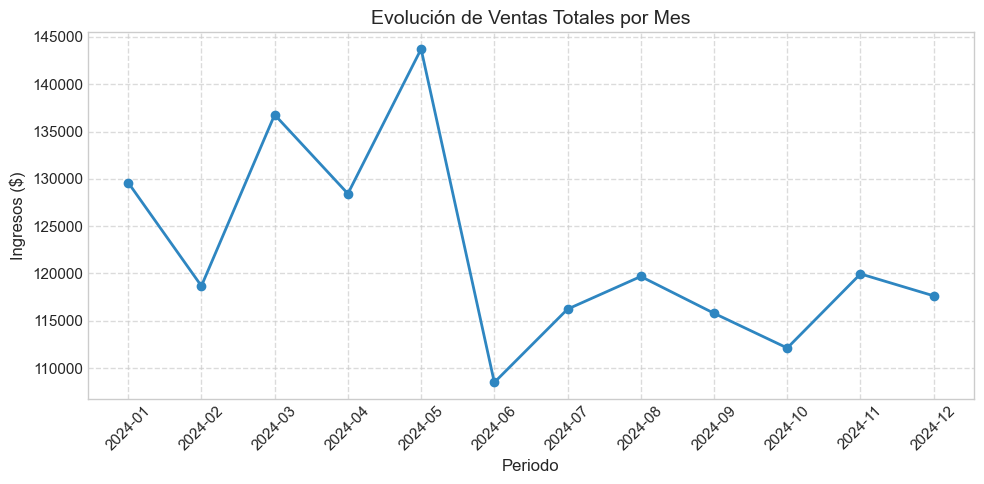

In [14]:
# 4.1: Matplotlib

# A. Gráfico de línea / Ventas mensuales
plt.figure(figsize=(10, 5))
plt.plot(
    ventas_mes['anio_mes_str'],
    ventas_mes['ingresos'],
    marker='o',
    color='#2E86C1',
    linestyle='-',
    linewidth=2
)
plt.title('Evolución de Ventas Totales por Mes', fontsize=14)
plt.xlabel('Periodo', fontsize=12)
plt.ylabel('Ingresos ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



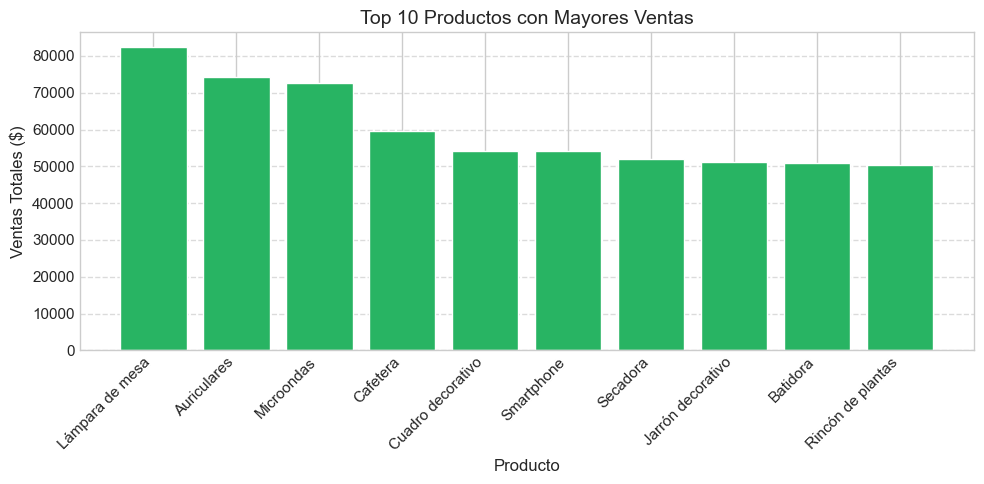

In [15]:
# B. Gráfico de barras / Top 10 productos

# El dataframe es el usado en 3.2

plt.figure(figsize=(10, 5))
plt.bar(
    top_10_productos['producto'],
    top_10_productos['ventas_total'],
    color='#28B463'
)
plt.title('Top 10 Productos con Mayores Ventas', fontsize=14)
plt.xlabel('Producto', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



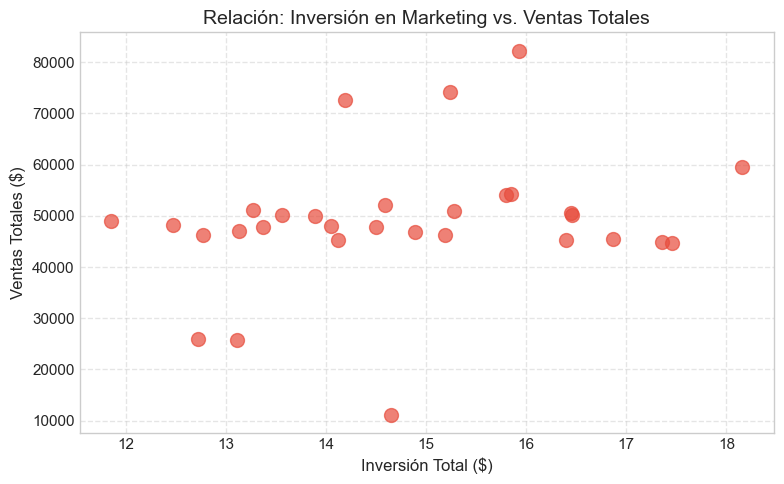

In [16]:
# C. Gráfico de dispersión / Inversión vs Ventas

plt.figure(figsize=(8, 5))
plt.scatter(
    df_final['inversion_total'],
    df_final['ventas_total'],
    color='#E74C3C',
    alpha=0.7,
    s=100
)
plt.title('Relación: Inversión en Marketing vs. Ventas Totales', fontsize=14)
plt.xlabel('Inversión Total ($)', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



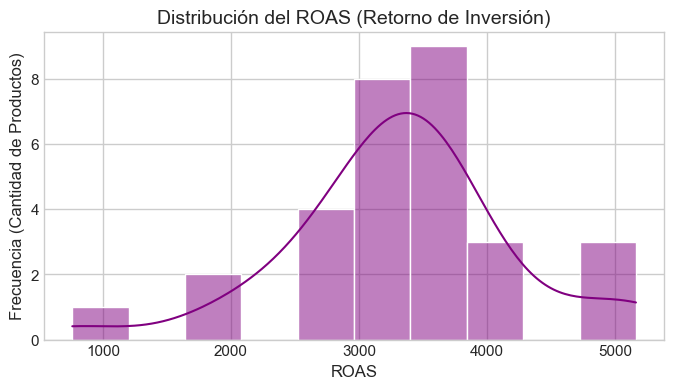

In [17]:
# 4.2: Visualización avanzada con Seaborn

# 1. Histograma de Distribución del ROAS
plt.figure(figsize=(8, 4))
sns.histplot(data=df_final, x='ROAS', kde=True, color='purple', bins=10)
plt.title('Distribución del ROAS (Retorno de Inversión)', fontsize=14)
plt.xlabel('ROAS')
plt.ylabel('Frecuencia (Cantidad de Productos)')
plt.show()



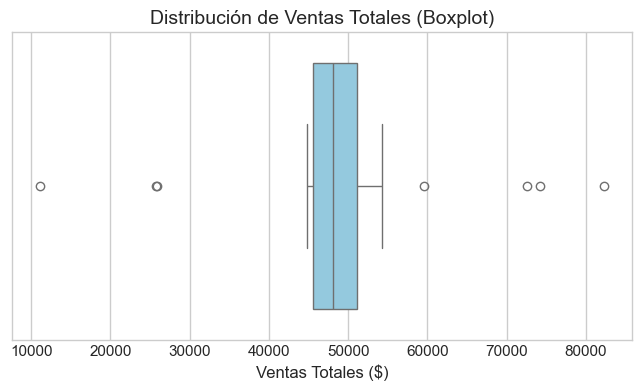

In [18]:
# 2. Boxplot de Ventas Totales (Para ver outliers y dispersión)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_final['ventas_total'], color='skyblue')
plt.title('Distribución de Ventas Totales (Boxplot)', fontsize=14)
plt.xlabel('Ventas Totales ($)')
plt.show()



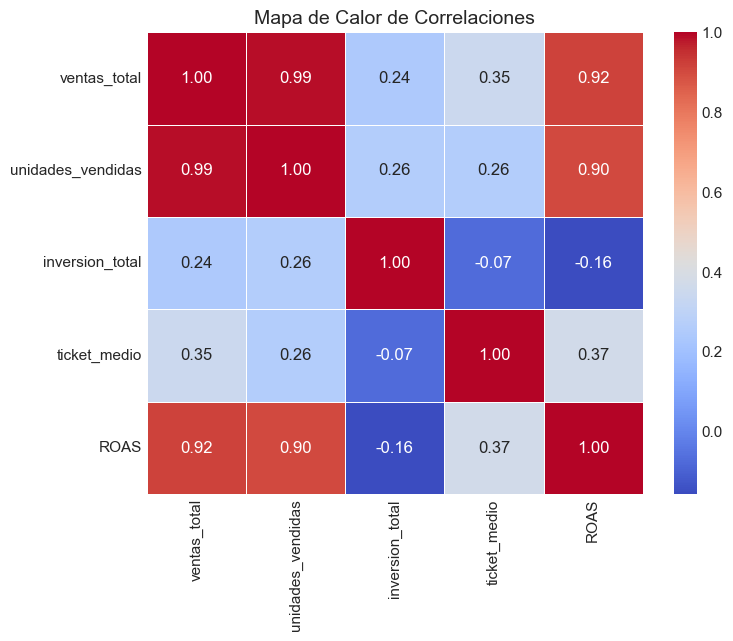

In [18]:
# 3. Heatmap de Correlación
# La matriz_corr se calculó en 3.3

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Mapa de Calor de Correlaciones', fontsize=14)
plt.show()



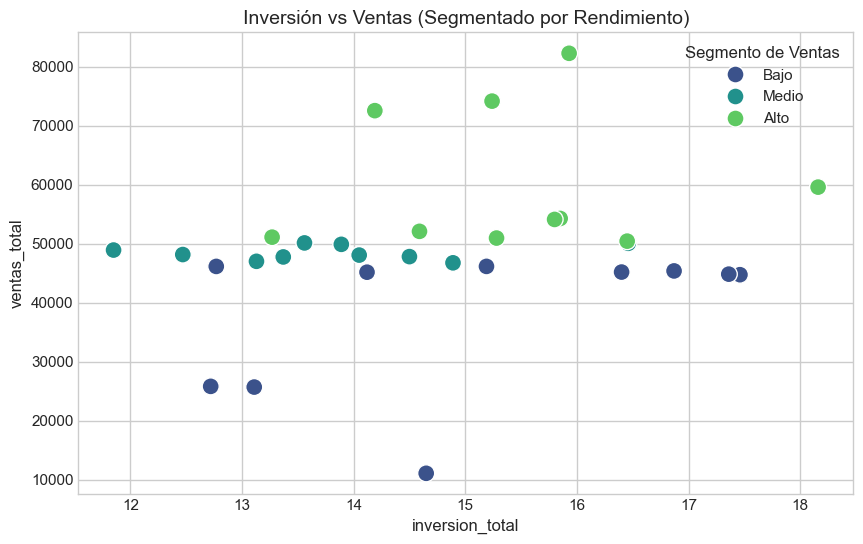

In [19]:
# 4. Scatter Plot con Segmentación (Hue)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final,
    x='inversion_total',
    y='ventas_total',
    hue='segmento_ventas',
    palette='viridis',
    s=150
)
plt.title('Inversión vs Ventas (Segmentado por Rendimiento)', fontsize=14)
plt.legend(title='Segmento de Ventas')
plt.show()

## 4.3: Dashboard Interactivo

In [20]:
# 4.3: Visualización Interactiva (Dashboard)

# 1. Preparar datos para el Dashboard
# Top 15 productos
df_top_15 = df_final.sort_values('ventas_total', ascending=False)

# 2. Crear la estructura del Dashboard (2 x 2)
fig_dashboard = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Top 15 Productos (Ventas Totales)",
        "Evolución Mensual de Ingresos",
        "Relación Inversión vs Ventas (Segmentado)",
        "Distribución del ROAS"
    ),
specs=[[{}, {}], [{}, {}]],
    vertical_spacing=0.35
)

# GRÁFICO 1: BARRAS (Top Productos)
fig_bar = px.bar(
    df_top_15, x='producto', y='ventas_total',
    color='ventas_total',
    hover_data=['ticket_medio', 'ROAS', 'categoria'],
    color_continuous_scale=['#FFDAB9', '#FFA07A', '#E9967A', '#F08080', '#CD5C5C']
)

for trace in fig_bar.data:
    fig_dashboard.add_trace(trace, row=1, col=1)


# GRÁFICO 2: LÍNEA (Evolución Mensual)
fig_line = px.line(
    ventas_mes,
    x='anio_mes_str',
    y='ingresos',
    markers=True
)
for trace in fig_line.data:
    fig_dashboard.add_trace(trace, row=1, col=2)


# GRÁFICO 3: SCATTER (Inversión vs Ventas)
fig_scatter = px.scatter(
    df_final, x="inversion_total", y="ventas_total",
    color="segmento_ventas", size="unidades_vendidas",
    hover_name="producto",
    color_discrete_sequence=['#66BB6A', '#FFA726', '#EF5350']
)
for trace in fig_scatter.data:
    fig_dashboard.add_trace(trace, row=2, col=1)


# GRÁFICO 4: HISTOGRAMA (ROAS)
fig_hist = px.histogram(
    df_final, x="ROAS", nbins=15,
    color_discrete_sequence=['purple'],
    opacity=0.7
)
for trace in fig_hist.data:
    fig_dashboard.add_trace(trace, row=2, col=2)

# LAYOUT
fig_dashboard.update_layout(
    title_text="Dashboard: Ventas y Marketing",
    title_font_size=20,
    showlegend=True,
    height=800,
    plot_bgcolor='white',
)

fig_dashboard.show()

c:\Users\karen\miniconda3\Lib\site-packages\plotly\express\_core.py:2044: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\karen\miniconda3\Lib\site-packages\plotly\express\_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



#  4.4:  Conclusiones

A partir del análisis de las bbdd presentadas, se encontraron distintos hallazgos acerca del rendimiento del negocio:

### 1. Ventas mensuales:
* Se observa bastante variabilidad en los ingresos mensuales.
* El mes de más ventas fue Mayo, seguido de una gran caída en Junio.
* Se recomienda investigar que campaña impulsó ese pico en Mayo para intentar replicarlo.


## 2. Productos de mejor performance:


*   La Lampara de mesa es el producto lider.
*   Le siguen artículos de tecnología y hogar, como Auriculares, Microondas, etc.
* Estos productos son la base de los ingresos de la empresa.

## 3. Efectividad del Marketing:
* Basandose en el mapa de calor y los gráficos de dispersión, existe una correlación baja entre la inversión total y las ventas_totales. Es decir, que gastar más en publicidad no garantiza más ventas necesariamente.
* La distribución del ROAS es normal, estando l amayoría de productos entre 3000 y 4000.
* En el scatter plot, hay productos verdes muy altos con inversión media, lo que diría que son naturalmente de alta venta.

## Recomendación:

En base a lo observado, recomendaría revisar la estrategia de marketing de los productos de alta inversión y bajas ventas. Además de aumentar la visibilidad de las categorías de decoración e iluminación, dado que contienen los productos más populares.